# 03 - Models and rankings under the microscope

[UFC_Pipeline](../UFC_Pipeline.ipynb) trains the models, scores them on the test period and publishes the rankings. This notebook reads what it saved in `data/processed/` and looks behind the headline numbers:

**Models**
1. Model selection on the validation period
2. Are the probabilities calibrated?
3. Confidence and accuracy
4. What the logistic regression learned
5. The model against the market

**Rankings**
6. Do the three methods agree?
7. Comparison with the official UFC rankings
8. Where the methods disagree
9. Tuning the Elo rating
10. Elo through history

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from ufc_rating import plotting
from ufc_rating.config import (
    ELO_HISTORY_CSV, MASTER_CSV, MODELS_PKL, PREDICTIONS_CSV, RANKINGS_CSV, WIKI_RANKINGS_CSV,
)
from ufc_rating.models.training import format_scores, load_models
from ufc_rating.processing.master import read_master, read_official_rankings
from ufc_rating.ranking.elo import CLOSE_DECISION_WEIGHT, K_FACTOR, compute_elo, peak_elo
from ufc_rating.ranking.rankings import compare_with_official, latest_official_ranks, method_agreement

plotting.setup()
bundle = load_models(MODELS_PKL)
results = bundle['results']
best = results['best_stats_model']
predictions = pd.read_csv(PREDICTIONS_CSV, parse_dates=['date'])
rankings = pd.read_csv(RANKINGS_CSV)
elo_history = pd.read_csv(ELO_HISTORY_CSV, parse_dates=['date'])
master = read_master(MASTER_CSV)

## 1. Model selection on the validation period

The hyperparameters of each model were tuned by time-ordered cross-validation inside the training period. The validation period, which none of the models was fitted on, then picks the stats model used for the round-robin rankings (lowest log loss).

In [2]:
print(f'Selected for the rankings: {best}')
format_scores(results['validation'])

Selected for the rankings: LogReg


,Fights,Accuracy,AUC,Log loss,Brier
LogReg,978,61.0%,0.672,0.645,0.227
SVM,978,61.5%,0.669,0.646,0.228
RandomForest,978,60.0%,0.657,0.655,0.232
XGBoost,978,60.9%,0.659,0.653,0.231
Elo only,978,56.4%,0.594,0.681,0.244


The four models land close to each other. The linear models (logistic regression, linear SVM) are at least as good as the tree ensembles: with a few thousand fights and features that are already differences between the two fighters, there is little non-linear structure left for the trees to find.

## 2. Are the probabilities calibrated?

For a rating system the probability matters more than the pick: a "60%" should win 60% of the time. Test-period predictions are grouped by predicted probability and compared with the observed win rate.

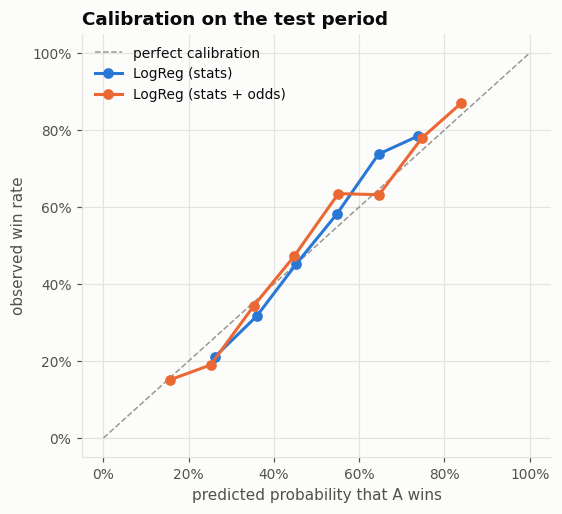

In [3]:
y = predictions['a_wins']
series = {f'{best} (stats)': predictions[f'{best} (stats)'],
          f'{best} (stats + odds)': predictions[f'{best} (stats + odds)']}

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.plot([0, 1], [0, 1], color=plotting.NEUTRAL, linewidth=1, linestyle='--', label='perfect calibration')
for (name, proba), color in zip(series.items(), plotting.SERIES):
    bins = pd.cut(proba, np.linspace(0, 1, 11))
    table = pd.DataFrame({'p': proba, 'y': y}).groupby(bins, observed=True).agg(p=('p', 'mean'), y=('y', 'mean'), n=('y', 'size'))
    table = table[table['n'] >= 20]
    ax.plot(table['p'], table['y'], marker='o', color=color, label=name)
ax.set_xlabel('predicted probability that A wins')
ax.set_ylabel('observed win rate')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title('Calibration on the test period')
ax.legend(loc='upper left')
plt.show()

Both models rank fights in the right order, but the stats-only model is **underconfident**: when it gives a fighter 55% or 65%, that fighter actually wins about 58% or 74% of the time. The strong regularisation chosen by cross-validation on the older fights pulls its probabilities towards 50%, and recent fights turn out to be more predictable than older ones. The odds give the second model the confidence to single out clear favourites, and it stays closer to the diagonal.

Underconfidence does not change which fighter is favoured, so accuracy, AUC and the round-robin order are unaffected; it does cost some log loss. Recalibrating on the validation period would be the next step.

## 3. Confidence and accuracy

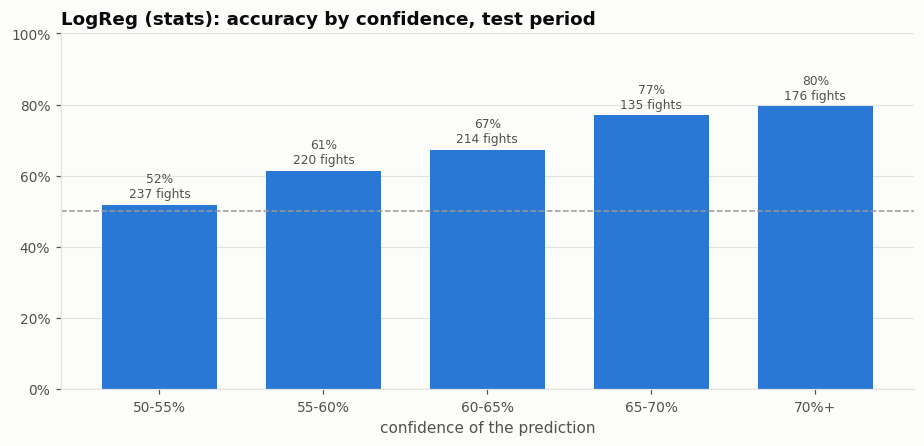

In [4]:
proba = predictions[f'{best} (stats)']
confidence = np.maximum(proba, 1 - proba)
correct = (proba > 0.5) == (y == 1)
buckets = pd.cut(confidence, [0.5, 0.55, 0.6, 0.65, 0.7, 1.0], include_lowest=True,
                 labels=['50-55%', '55-60%', '60-65%', '65-70%', '70%+'])
by_confidence = pd.DataFrame({'correct': correct, 'bucket': buckets}).groupby('bucket', observed=False)['correct'].agg(['mean', 'size'])

ax = by_confidence['mean'].plot.bar(color=plotting.BLUE, width=0.7)
ax.axhline(0.5, color=plotting.NEUTRAL, linewidth=1, linestyle='--')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_ylim(0, 1)
ax.set_title(f'{best} (stats): accuracy by confidence, test period')
ax.set_xlabel('confidence of the prediction')
ax.tick_params(axis='x', rotation=0)
ax.grid(axis='x', visible=False)
for x, (acc, n) in enumerate(by_confidence.itertuples(index=False)):
    ax.text(x, acc + 0.02, f'{acc:.0%}\n{n} fights', ha='center', fontsize=8, color=plotting.INK_SECONDARY)
plt.show()

Accuracy rises with confidence, as it should. A large share of fights sits in the 50-60% band where the model honestly does not know: UFC matchmaking pairs fighters of similar level on purpose.

## 4. What the logistic regression learned

The features are scaled to unit variance, so each coefficient is the change in log-odds of winning for a one-standard-deviation advantage over the opponent.

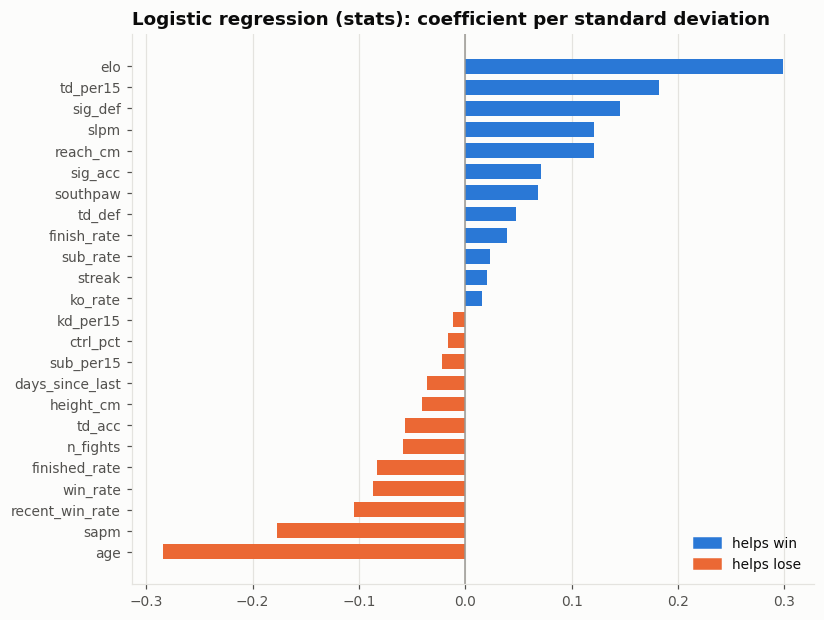

In [5]:
logreg = bundle['stats']['LogReg'].named_steps['model']
coefs = pd.Series(logreg.coef_[0], index=[f.removeprefix('delta_') for f in bundle['stats_features']]).sort_values()

colors = [plotting.BLUE if c > 0 else plotting.ORANGE for c in coefs]
fig, ax = plt.subplots(figsize=(8, 6.5))
ax.barh(coefs.index, coefs.values, color=colors, height=0.7)
ax.axvline(0, color=plotting.NEUTRAL, linewidth=1)
ax.set_title('Logistic regression (stats): coefficient per standard deviation')
ax.grid(axis='y', visible=False)
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in (plotting.BLUE, plotting.ORANGE)]
ax.legend(handles, ['helps win', 'helps lose'], loc='lower right')
plt.show()

- The largest weights go to **Elo** and **age** (the younger fighter), then **takedown volume**, **strikes absorbed** (fewer is better), striking defence and output, and **reach**: the same signals as in the single-feature analysis of [02_feature_engineering](02_feature_engineering.ipynb).
- The raw win rate and recent form get *negative* weights. This does not mean that winning is bad: Elo and the streak already summarise the record, and among strongly correlated features the regression only keeps a small correction on the extra ones. Coefficients of correlated features have to be read together.
- The strong L2 regularisation chosen by cross-validation keeps every coefficient small. Since the model has no intercept and only differences as inputs, it has no notion of corner or card position.

## 5. The model against the market

On the test fights with odds: how often does the stats model pick the same winner as the bookmakers, and when they disagree, who is right?

In [6]:
market = predictions.dropna(subset=['a_odds_prob'])
model_pick = market[f'{best} (stats)'] > 0.5
market_pick = market['a_odds_prob'] > 0.5
a_won = market['a_wins'] == 1
agree = model_pick == market_pick

summary = pd.DataFrame({
    'fights': [agree.sum(), (~agree).sum()],
    'model right': [(model_pick == a_won)[agree].mean(), (model_pick == a_won)[~agree].mean()],
    'market right': [(market_pick == a_won)[agree].mean(), (market_pick == a_won)[~agree].mean()],
}, index=['model and market agree', 'they disagree'])
summary[['model right', 'market right']] = summary[['model right', 'market right']].map('{:.1%}'.format)
summary

,fights,model right,market right
model and market agree,721,72.7%,72.7%
they disagree,190,40.5%,59.5%


The two agree on most fights. When they disagree, the market is right more often than the model: its extra information (injuries, short-notice replacements, weight cuts, stylistic match-ups) is exactly what public fight statistics cannot see.

## 6. Do the three methods agree?

Spearman correlation between the ranks given by each pair of methods, per division (1 = identical order).

In [7]:
method_agreement(rankings)

,fighters,Elo vs Weighted,Elo vs Model,Weighted vs Model
division,,,,
Flyweight,35,0.78,0.91,0.76
Bantamweight,53,0.73,0.80,0.76
Featherweight,56,0.70,0.78,0.73
Lightweight,77,0.80,0.82,0.78
Welterweight,65,0.77,0.85,0.81
Middleweight,56,0.67,0.88,0.76
Light Heavyweight,34,0.69,0.72,0.79
Heavyweight,33,0.88,0.86,0.91
Women's Strawweight,37,0.75,0.84,0.84


The three methods agree broadly (correlations mostly between 0.6 and 0.9) while measuring different things: Elo rewards results against rated opponents, the weighted score rewards a style, the model rewards the profile that wins fights.

## 7. Comparison with the official UFC rankings

The latest weekly snapshot of the official rankings (from Wikipedia) is compared with the rank each method gives, per division, over the fighters present in both lists (Spearman correlation, 1 = same order). Two official rankings exist since June 2026: the **media panel**, voted by journalists, and the **Meta UFC Rankings**, computed by a rating model built with Meta.

In [8]:
official = read_official_rankings(WIKI_RANKINGS_CSV, master)
comparisons = {}
for system, label in (('media', 'media panel'), ('meta', 'Meta UFC Rankings')):
    latest = latest_official_ranks(official, system)
    comparisons[label] = compare_with_official(rankings, latest)
    print(f"{label}: snapshot of {latest['rank_date'].iloc[0].date()}")
pd.concat(comparisons, axis=1)

media panel: snapshot of 2026-09-22
Meta UFC Rankings: snapshot of 2026-09-22


media panel                       \
                     ranked fighters compared   Elo Weighted Model   
division                                                             
Flyweight                                  15  0.73     0.72  0.55   
Bantamweight                               15  0.81     0.22  0.49   
Featherweight                              13  0.93     0.37  0.63   
Lightweight                                14  0.83     0.49  0.49   
Welterweight                               14  0.84     0.40  0.85   
Middleweight                               16  0.91     0.02  0.41   
Light Heavyweight                          15  0.57     0.32  0.41   
Heavyweight                                11  0.92     0.69  0.89   
Women's Strawweight                        13  0.98     0.40  0.69   
Women's Flyweight                          15  0.96     0.27  0.64   
Women's Bantamweight                       12  0.81     0.47  0.27   

                            Meta UFC Rankings                       
                     ranked fighters compared   Elo Weighted Model  
division                                                            
Flyweight                                  13  0.80     0.80  0.58  
Bantamweight                               15  0.87     0.38  0.59  
Featherweight                              13  0.93    -0.03  0.50  
Lightweight                                14  0.80     0.36  0.35  
Welterweight                               14  0.82     0.45  0.85  
Middleweight                               16  0.95     0.16  0.53  
Light Heavyweight                          14  0.50     0.42  0.31  
Heavyweight                                12  0.94     0.69  0.88  
Women's Strawweight                        13  0.87     0.27  0.58  
Women's Flyweight                          15  0.92     0.01  0.34  
Women's Bantamweight                       11  0.45     0.58  0.50

In [9]:
pd.concat({label: table[['Elo', 'Weighted', 'Model']].mean() for label, table in comparisons.items()}, axis=1).round(2).rename_axis('mean over divisions')

,media panel,Meta UFC Rankings
mean over divisions,,
Elo,0.84,0.80
Weighted,0.40,0.37
Model,0.57,0.55


Elo is by far the closest to both official rankings, and the closest in every division of the media panel. That is expected: the panel ranks fighters by *who they beat*, the Meta UFC Rankings are themselves a rating model that weighs the quality of the opponents, and Elo is the only one of our methods that knows the opponents. Against the Meta rankings Elo is matched in flyweight and beaten in women's bantamweight, the division where the two official rankings disagree the most ([01_exploration](01_exploration.ipynb)).

The weighted and model rankings judge how a fighter fights, regardless of opposition, so they rate highly some prospects the UFC has not tested against ranked opposition yet. The weighted score is the furthest from the official lists: it measures a style, and its weights are a choice, not a fit (they are set at the top of [UFC_Pipeline](../UFC_Pipeline.ipynb)).

## 8. Where the methods disagree

Among each division's current top 10 by consensus, the fighters whose three ranks are furthest apart.

In [10]:
top = rankings[rankings['rank'] <= 10].copy()
rank_cols = ['Elo rank', 'Weighted rank', 'Model rank']
top['spread'] = top[rank_cols].max(axis=1) - top[rank_cols].min(axis=1)
(top.sort_values('spread', ascending=False)
    .head(10)[['division', 'Fighter', 'UFC record', 'Elo', 'Weighted', 'Model'] + rank_cols]
    .reset_index(drop=True))

,division,Fighter,UFC record,Elo,Weighted,Model,Elo rank,Weighted rank,Model rank
0,Welterweight,Ian Machado Garry,10-2,1796,0.530,0.749,6,25,5
1,Lightweight,Dustin Poirier,22-9,1782,0.734,0.590,5,7,23
2,Bantamweight,Payton Talbott,5-1,1658,0.824,0.671,18,1,10
3,Lightweight,Mateusz Gamrot,9-5,1711,0.621,0.751,11,21,5
4,Welterweight,Max Holloway,24-9,1889,0.616,0.683,2,18,10
5,Light Heavyweight,Robert Whittaker,18-7,1799,0.485,0.647,3,18,6
6,Welterweight,Mike Malott,7-1,1721,0.760,0.619,14,2,16
7,Bantamweight,Raul Rosas Jr.,6-1,1659,0.686,0.767,17,9,3
8,Featherweight,Movsar Evloev,10-0,1840,0.621,0.795,3,15,1
9,Women's Strawweight,Iasmin Lucindo,5-2,1614,0.570,0.743,9,17,3


Two typical cases:

- **Proven veterans**: a long record against strong opponents gives a high Elo, while an older profile, recent losses or a grinding style pull down the statistical methods.
- **Young prospects**: excellent statistics and at most one loss push the weighted and model ranks up, but with few UFC fights against rated opponents their Elo is still well below the veterans'.

## 9. Tuning the Elo rating

Two settings define the Elo rating: **K**, how many points a single fight can move (the textbook value for chess is 32), and how much a **split or majority decision** counts, since the judges themselves disagreed on the winner. They were chosen on the fights from 2005 up to the start of the test period, by the log loss of Elo-only predictions (the pre-fight ratings turned into a win probability). The grid below reruns that choice.

In [11]:
test_start = predictions['date'].min()
scored = master[master['outcome'].isin(['r', 'b']) & (master['date'] >= '2005-01-01') & (master['date'] < test_start)]
r_won = (scored['outcome'] == 'r').to_numpy()

def elo_log_loss(k, close_weight):
    before = compute_elo(master, k=k, close_weight=close_weight).set_index(['fight_id', 'fighter_id'])['elo_before']
    r = before.reindex(pd.MultiIndex.from_arrays([scored['fight_id'], scored['r_id']])).to_numpy()
    b = before.reindex(pd.MultiIndex.from_arrays([scored['fight_id'], scored['b_id']])).to_numpy()
    p_r = 1 / (1 + 10 ** ((b - r) / 400))
    return -np.mean(np.log(np.where(r_won, p_r, 1 - p_r)))

grid = pd.DataFrame({weight: {k: elo_log_loss(k, weight) for k in (32, 48, 64, 80, 96, 128)}
                     for weight in (1.0, 0.5, 0.25)})
grid.index.name = 'K'
grid.columns.name = 'weight of a split / majority decision'
print(f'{len(scored):,} fights scored. Chosen: K = {K_FACTOR:.0f}, close decisions weighted {CLOSE_DECISION_WEIGHT}.')
grid.round(4)

7,109 fights scored. Chosen: K = 80, close decisions weighted 0.5.


weight of a split / majority decision,1.00,0.50,0.25
K,,,
32,0.6839,0.6830,0.6827
48,0.6818,0.6804,0.6800
64,0.6807,0.6788,0.6783
80,0.6804,0.6781,0.6776
96,0.6809,0.6782,0.6777
128,0.6842,0.6805,0.6801


Two findings:

- **K should be much larger than in chess.** A UFC fighter has a few fights a year and a career of a few dozen at most, so the rating has to move fast to follow them. The log loss is lowest between K = 64 and 96 and rises again beyond.
- **Close decisions should count less, at every K.** Halving the weight of split and majority decisions improves the fit whatever the value of K.

The best cell of the grid (K = 80 with a weight of 0.25) is barely better than the chosen one (K = 80, weight 0.5), a difference too small to matter; half a win is the more natural value and the one kept. Against the textbook K = 32 with every win counted the same, the chosen setting improves the Elo-only log loss by about 0.006, far more than any of the feature groups tested in [02_feature_engineering](02_feature_engineering.ipynb).

## 10. Elo through history

In [12]:
peak_elo(elo_history, top=15)

,Fighter,Peak Elo,Reached on
1,Jon Jones,2055,2024-11-16
2,Islam Makhachev,2051,2026-08-15
3,Kamaru Usman,2006,2021-11-06
4,Georges St-Pierre,1988,2017-11-04
5,Merab Dvalishvili,1954,2025-10-04
6,Leon Edwards,1950,2023-12-16
7,Alexander Volkanovski,1947,2022-07-02
8,Anderson Silva,1947,2012-10-13
9,Belal Muhammad,1940,2024-07-27
10,Khabib Nurmagomedov,1935,2020-10-24


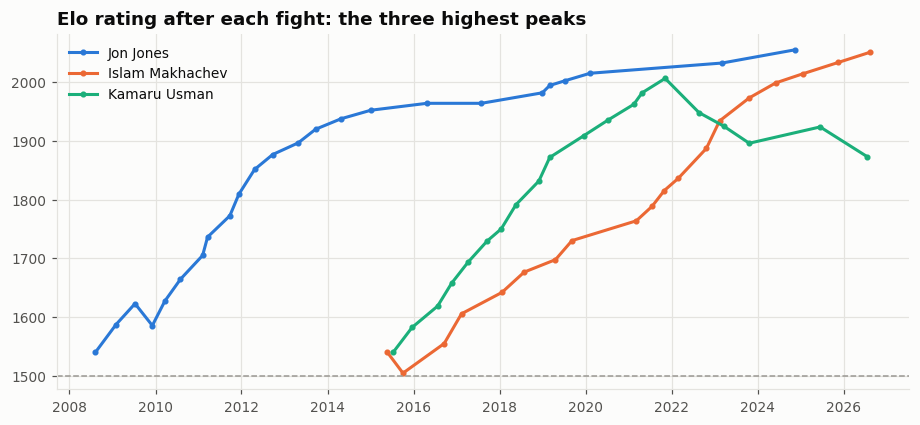

In [13]:
legends = list(peak_elo(elo_history, top=3)['Fighter'])
fig, ax = plt.subplots()
for name, color in zip(legends, plotting.SERIES):
    career = elo_history[elo_history['fighter_name'] == name].sort_values('date')
    ax.plot(career['date'], career['elo_after'], marker='o', markersize=3, color=color, label=name)
ax.axhline(1500, color=plotting.NEUTRAL, linewidth=1, linestyle='--')
ax.set_title('Elo rating after each fight: the three highest peaks')
ax.set_xlabel('')
ax.legend(loc='upper left')
plt.show()

Elo climbs with every win and drops after a loss, more sharply when the loss is an upset (Jones's 2009 disqualification, Makhachev's 2015 knockout); a no contest leaves it unchanged. The highest peaks come from long winning runs against rated opposition, so the length of a career matters: Khabib Nurmagomedov, unbeaten in 13 UFC fights, peaks lower (10th) than fighters who won for longer.